# 🚂 Entrenamiento y comparativa (final, sobre `src`)

> **Capa final:** este notebook **ORQUESTA** el pipeline de `src/` (entrenar los 5 modelos, elegir el mejor por ROC-AUC) y muestra los resultados. La exploración manual por modelo, estilo `recursos/`, vive en `notebooks/playground/`. Glosario: `../docs/glosario.md`.

A diferencia de los notebooks de *playground* (que reimplementan cada algoritmo a mano con fines didácticos), aquí **no reescribimos nada**: llamamos a las mismas funciones de `src/ml_hotel_cancellations/` que se ejecutan en producción cuando lanzas `python -m ml_hotel_cancellations.ml.train`. Lo que ves a continuación es, por tanto, el pipeline real del proyecto.

## Configuración

Importamos el **contrato** del proyecto (`config`) y las dos piezas que orquestaremos: `load_and_prepare` (carga + limpieza + partición) y `run_pipeline` (entrena, evalúa, selecciona y persiste artefactos).

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')  # silencia logs de TensorFlow
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from IPython.display import Image, display

from ml_hotel_cancellations import config
from ml_hotel_cancellations.ml.data_loader import load_and_prepare
from ml_hotel_cancellations.ml.train import run_pipeline

## 1. Los datos del pipeline

`load_and_prepare()` ejecuta el flujo completo de datos —carga del CSV crudo, limpieza (elimina *leakage* y reservas sin huéspedes, normaliza categóricas) y **partición estratificada** train/test— y devuelve `(X_train, X_test, y_train, y_test)`.

In [2]:
X_train, X_test, y_train, y_test = load_and_prepare()

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")
print(f"Tasa de cancelación (train): {y_train.mean():.3f}   (test): {y_test.mean():.3f}")

X_train: (95368, 28)   y_train: (95368,)
X_test : (23842, 28)   y_test : (23842,)
Tasa de cancelación (train): 0.371   (test): 0.371


Es exactamente la **misma partición estratificada que usa producción** (semilla fija `random_state = 42`, `test_size = 0.2`), por lo que la tasa de cancelación (~37 %) se conserva en ambos conjuntos.

## 2. Entrenar y seleccionar

`run_pipeline(tune=False)` es el corazón del proyecto. En una sola llamada:

1. Vuelve a cargar y preparar los datos (misma partición).
2. **Entrena los 5 modelos** de `config.MODEL_FAMILY` (cada uno es un `Pipeline`    preprocesado + algoritmo):
   - **Logistic Regression** (familia *linear*)
   - **Decision Tree** (familia *tree*)
   - **Random Forest** (familia *forest*)
   - **XGBoost** (familia *boosting*)
   - **Neural Network (Keras)** (familia *neural_net*)

3. Los **evalúa** sobre el conjunto de test y construye la tabla comparativa.
4. **Elige el mejor** según la métrica principal `config.PRIMARY_METRIC = 'roc_auc'`.
5. **Persiste los artefactos**: los 5 modelos en `models/`, el mejor en    `models/best_model.pkl`, la tabla de métricas en `outputs/metricas_modelos.csv` y    las figuras PNG en `outputs/`.

Devuelve la tupla `(tabla, mejor)`: la tabla comparativa (DataFrame) y el nombre del modelo ganador.

> ⏱️ Entrenar los 5 modelos (incluida la red neuronal Keras) tarda un rato. Con `tune=False` reutiliza los hiperparámetros óptimos guardados si existen.

In [3]:
tabla, mejor = run_pipeline(tune=False)
print("\nMejor modelo:", mejor)


RESUMEN DE LA COMPARATIVA DE MODELOS
                        accuracy  precision  recall     f1  roc_auc  train_time_s
XGBoost                   0.8934     0.8701  0.8374 0.8535   0.9614        4.5374
Neural Network (Keras)    0.8708     0.8453  0.7975 0.8207   0.9459       11.9017
Random Forest             0.8644     0.8828  0.7313 0.8000   0.9455        2.3587
Decision Tree             0.8551     0.8191  0.7819 0.8000   0.9329        0.9127
Logistic Regression       0.8190     0.7314  0.8088 0.7682   0.9064        1.3695
----------------------------------------------------------------------
Métrica principal de selección : roc_auc
MEJOR MODELO                   : XGBoost
Artefactos guardados en        : /home/manu/dev/github.com/manupm87/pontia-ml/outputs y /home/manu/dev/github.com/manupm87/pontia-ml/models


Mejor modelo: XGBoost


Tras esta celda, `models/` y `outputs/` quedan reescritos con los artefactos recién generados. Las secciones siguientes simplemente los muestran.

## 3. Comparativa de modelos

La tabla ya viene **ordenada por `roc_auc` descendente** (la métrica de selección). Recordatorio rápido (detalle en `../docs/glosario.md`):

- **accuracy**: % de aciertos totales. **precision**: de las marcadas "cancela", cuántas lo eran. **recall**: de las cancelaciones reales, cuántas detecté. **F1**: equilibrio precision/recall. **ROC-AUC**: capacidad de *ordenar* por riesgo (0.5 = azar, 1 = perfecto).

In [4]:
# Coloreamos para leer mejor; alternativamente: pd.read_csv(config.METRICS_TABLE_PATH, index_col=0)
metricas = [m for m in config.METRIC_NAMES if m in tabla.columns]
tabla.style.background_gradient(cmap='Greens', subset=metricas).format('{:.4f}')

,accuracy,precision,recall,f1,roc_auc,train_time_s
XGBoost,0.8934,0.8701,0.8374,0.8535,0.9614,4.5374
Neural Network (Keras),0.8708,0.8453,0.7975,0.8207,0.9459,11.9017
Random Forest,0.8644,0.8828,0.7313,0.8000,0.9455,2.3587
Decision Tree,0.8551,0.8191,0.7819,0.8000,0.9329,0.9127
Logistic Regression,0.8190,0.7314,0.8088,0.7682,0.9064,1.3695


**Lectura.** **XGBoost** gana con un **ROC-AUC ≈ 0.9614**, seguido de cerca por la red neuronal y el Random Forest. Elegimos `roc_auc` como métrica principal porque es **robusta al desbalance** (~37 % cancelaciones), **no depende del umbral** (`config.DECISION_THRESHOLD = 0.5` puede ajustarse luego según la política de *overbooking*) y es **comparable** entre algoritmos muy distintos.

## 4. Curvas ROC, matriz de confusión e importancia de variables

`run_pipeline` guarda como PNG en `outputs/` las figuras exigidas por el enunciado. Las mostramos directamente desde disco.

### Curva ROC comparativa

Para cada modelo, equilibrio entre **detectar cancelaciones** (eje Y, *TPR*) y **dar falsas alarmas** (eje X, *FPR*) al variar el umbral. Cuanto más se acerca la curva a la **esquina superior izquierda**, mejor; el **AUC** resume cada curva.

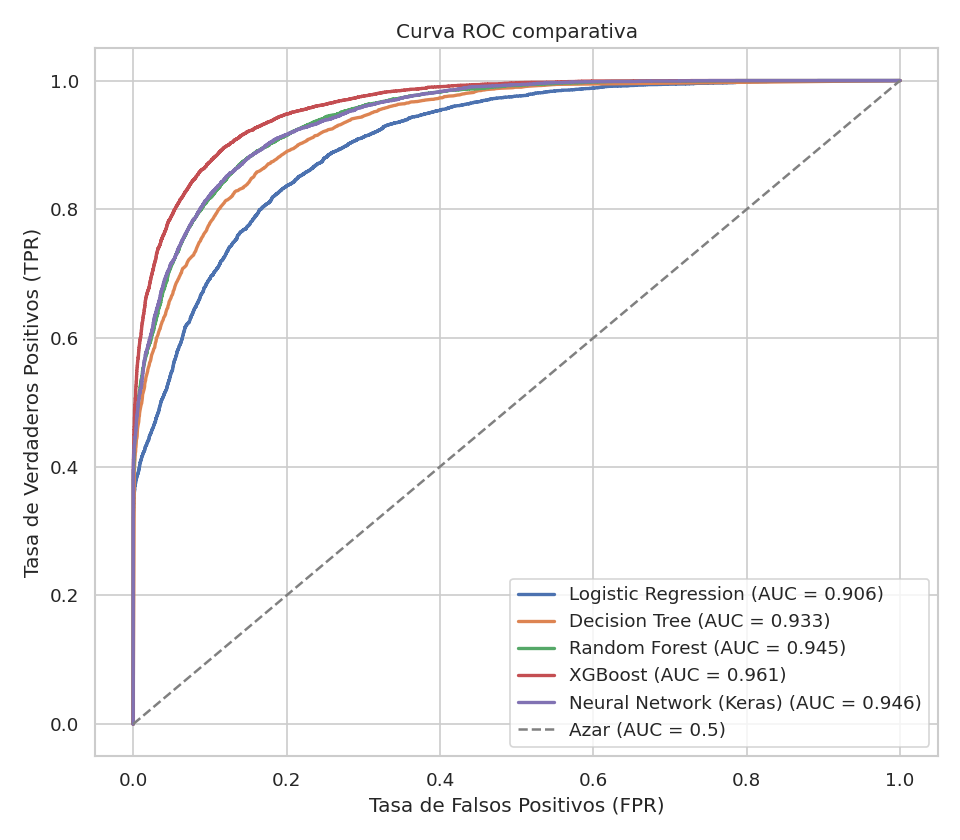

In [5]:
display(Image(str(config.OUTPUTS_DIR / 'roc_curves.png')))

### Matriz de confusión del mejor modelo

Cruza lo que el modelo **predijo** con lo que **realmente pasó**. La **diagonal** son aciertos; fuera de ella, los errores: *falsos positivos* (falsa alarma) y *falsos negativos* (cancelación que se escapó).

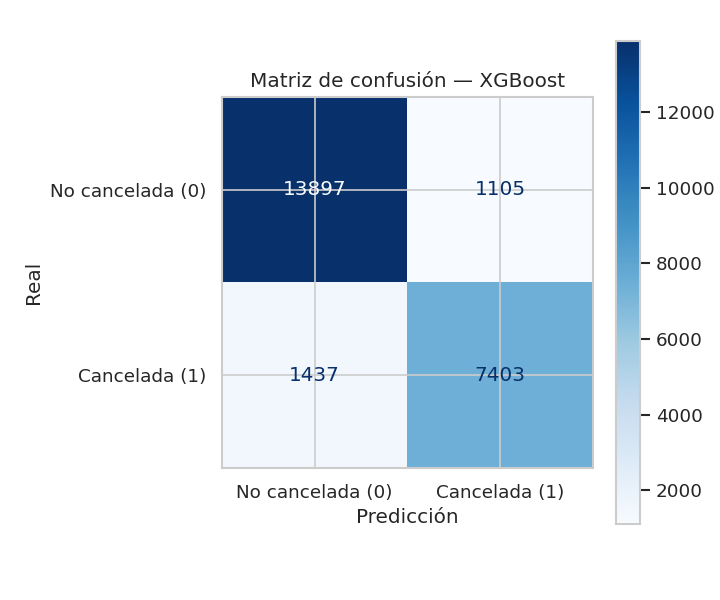

In [6]:
display(Image(str(config.OUTPUTS_DIR / 'confusion_matrix_best.png')))

### Importancia de variables (Random Forest)

Cuánto influye cada característica en las decisiones del modelo. Las más influyentes coinciden con el EDA: `deposit_type=Non Refund`, `lead_time` (antelación), `adr` (precio), `country` y `total_of_special_requests`. Que el modelo "razone" con variables que **tienen sentido** aumenta nuestra confianza en él.

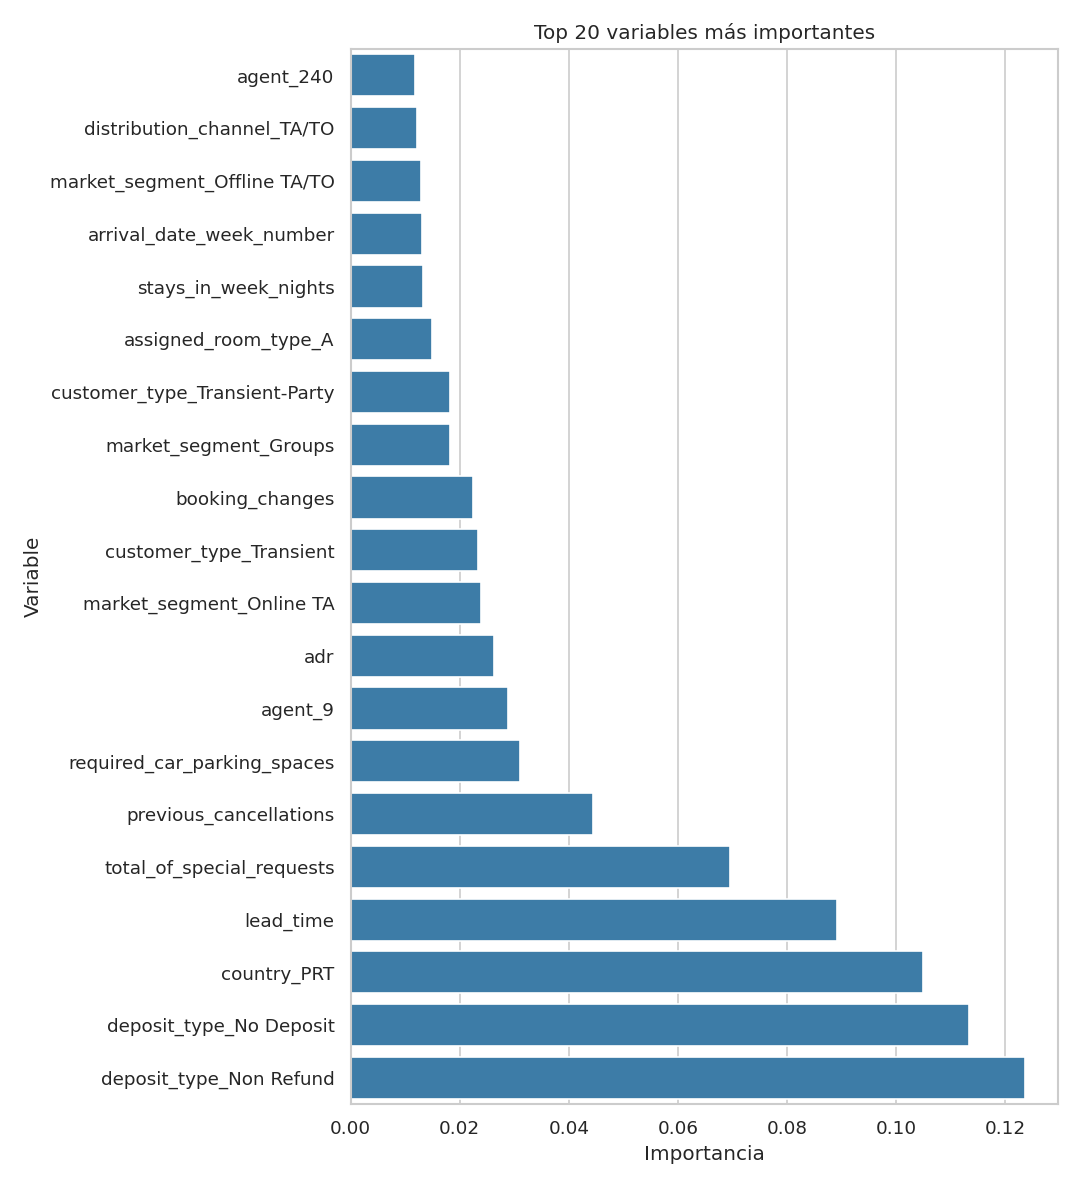

In [7]:
display(Image(str(config.OUTPUTS_DIR / 'feature_importance.png')))

## 5. Visualización 2D (PLS): regiones de decisión

Queremos *ver* en un plano cómo separa cada modelo las cancelaciones. El obstáculo (visto en el EDA): la señal que separa las cancelaciones es en gran parte **categórica** (`deposit_type`, `country`...), así que un *scatter* de dos variables continuas sale muy solapado, y **PCA** —que elige las direcciones de mayor varianza ignorando la clase— mezcla los grupos.

**La solución: PLS** (*Partial Least Squares*). Proyecta a 2D **mirando el `target`**: elige las 2 direcciones más correlacionadas con `is_canceled`, así que las clases *sí* se separan (la **componente 1** funciona como un *índice de riesgo*). Sobre ese plano se reentrena cada modelo y se pintan sus **regiones de decisión** (rojo = predice cancelación, azul = no; línea negra = frontera 0.5). Esta figura la genera el utilitario `utils/visualization_2d`; aquí la mostramos desde `outputs/`.

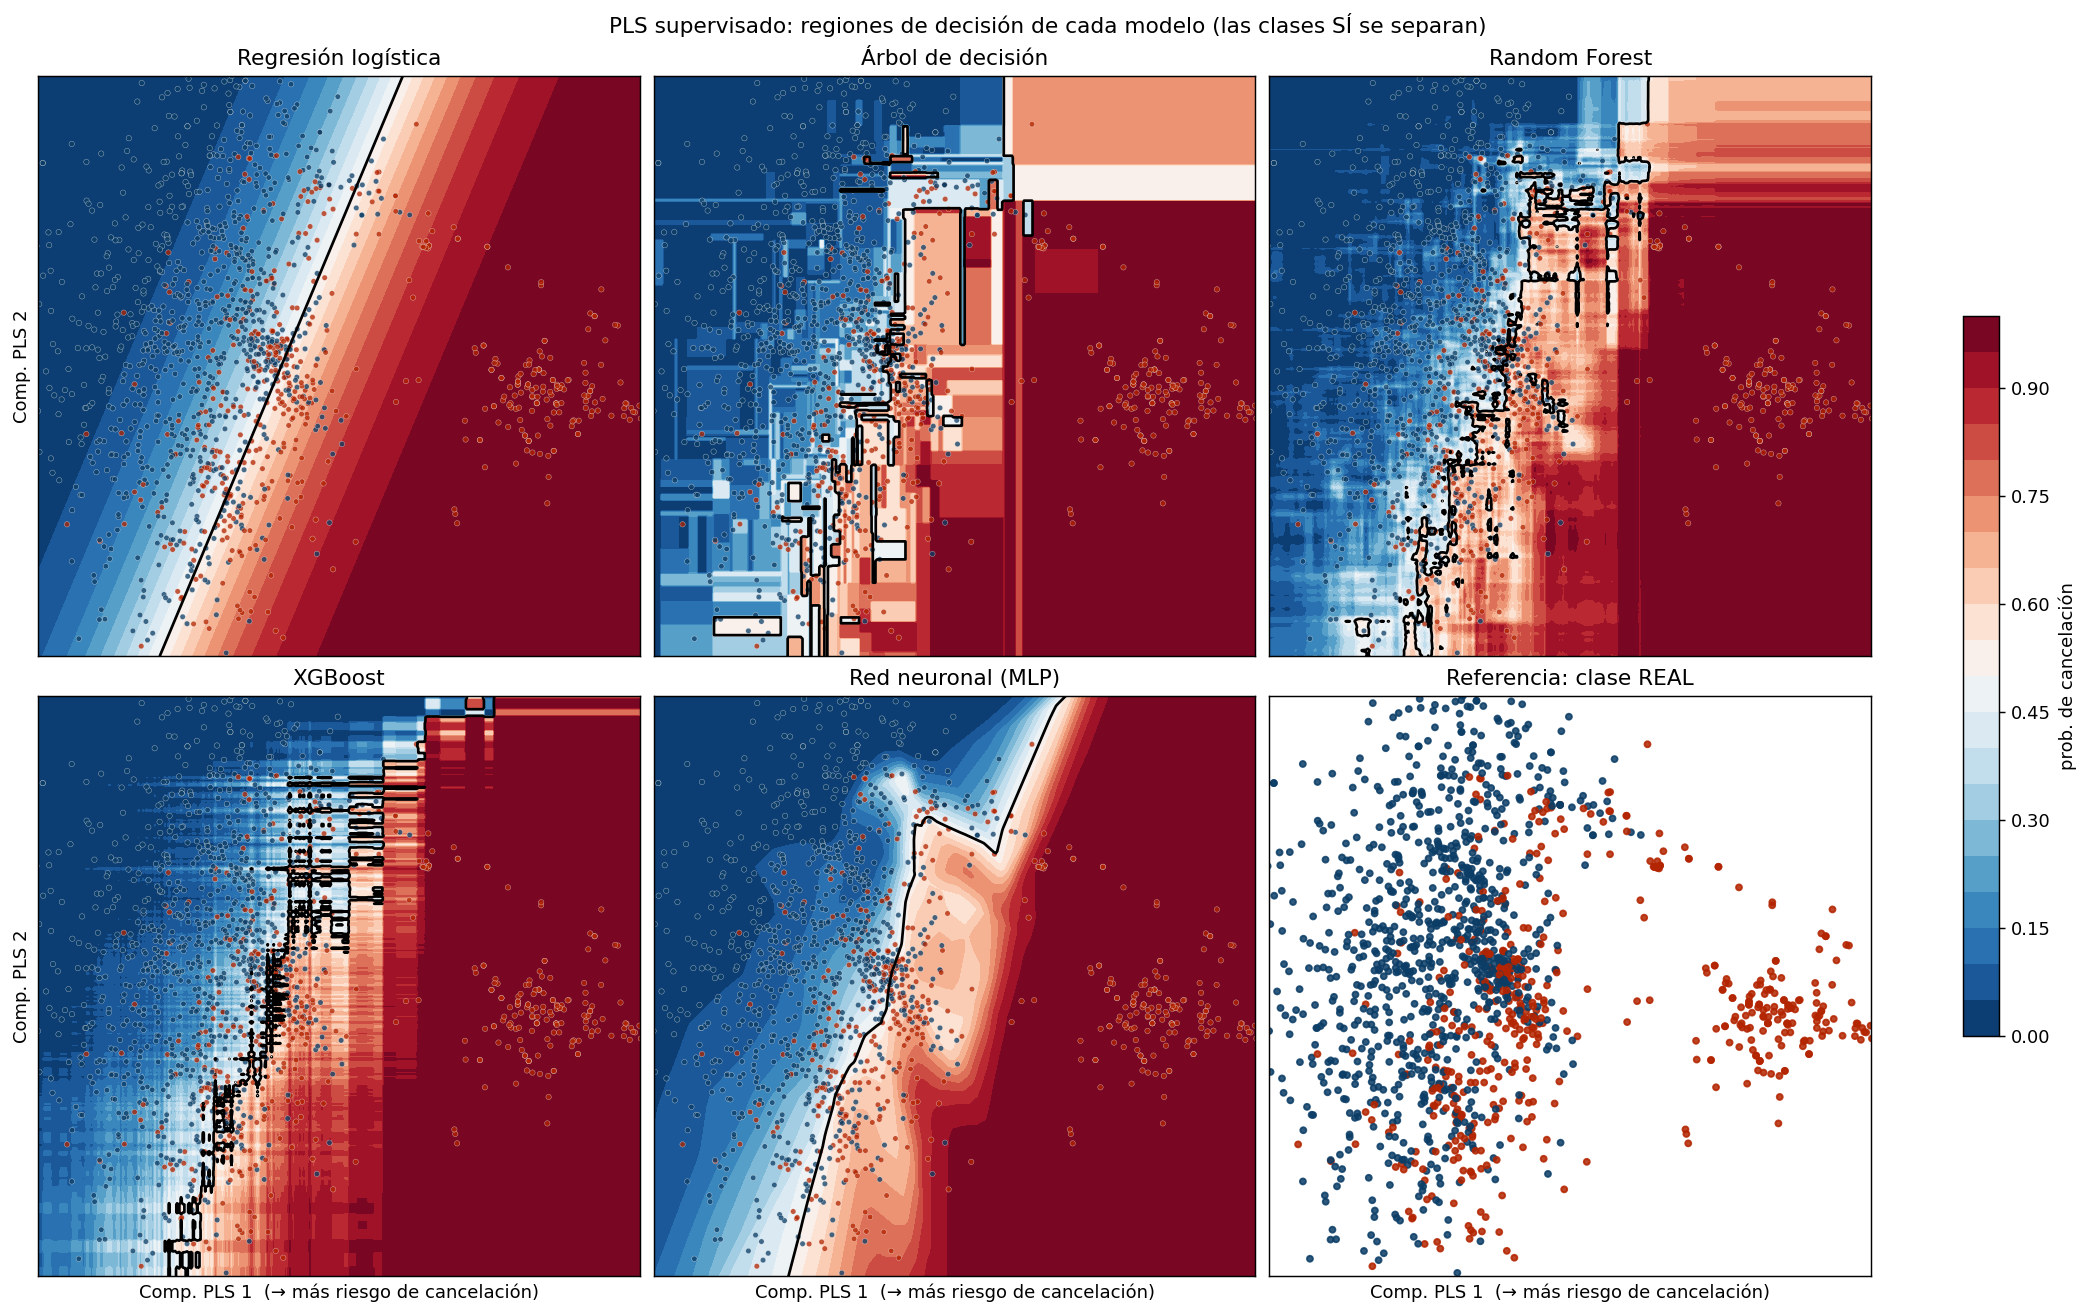

In [8]:
display(Image(str(config.OUTPUTS_DIR / 'decision_regions_pls.png')))

**Lectura.** Azul (no cancela) a la izquierda, rojo (cancela) a la derecha, siguiendo el eje de riesgo. Se aprecia la **personalidad** de cada modelo —logística recta, árbol en bloques, Random Forest más limpio, XGBoost fragmentado, red neuronal suave— pero **todos separan bien**, porque las 2 componentes PLS ya concentran casi toda la señal (incluida la de las categóricas).

## 6. Conclusión

**XGBoost** es el modelo de producción: mejor **ROC-AUC ≈ 0.9614**, rápido de entrenar e inferir. `run_pipeline` lo ha guardado en **`models/best_model.pkl`**, que es exactamente el artefacto que **sirve la API** (FastAPI) y que consume la interfaz Streamlit.

- Métrica de selección: `config.PRIMARY_METRIC = 'roc_auc'`. Umbral de decisión: `config.DECISION_THRESHOLD = 0.5`.
- Para **usar el modelo** sobre reservas nuevas (inferencia), continúa en el notebook **`05_...`** de inferencia.
- Limitaciones y líneas de mejora: `../docs/informe_final.md`. Glosario: `../docs/glosario.md`.